NOTE: YOLO's Python interface allows for seamless integration into your Python projects, making it easy to load, run, and process the model's output.

In [2]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('weights/best.pt')
image = Image.open("images/test_image.jpg")
result = model.predict(image, conf=0.25)[0]


0: 640x416 1 botleft, 1 botright, 1 topleft, 1 topright, 55.3ms
Speed: 4.0ms preprocess, 55.3ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 416)


In [3]:
result.boxes.xyxy

tensor([[ 196.9029,  401.3098,  273.1887,  480.3156],
        [ 169.5745,  799.4218,  297.0216,  915.5203],
        [ 983.1586,  393.4318, 1057.0204,  503.1259],
        [ 951.1082,  833.6973, 1031.9592,  923.3998]], device='cuda:0')

In [4]:
result.boxes.conf

tensor([0.8962, 0.8172, 0.7988, 0.7286], device='cuda:0')

result.boxes.cls

**NOTE:** YOLO11 can be easily integrated with `supervision` using the familiar `from_ultralytics` connector.

In [5]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

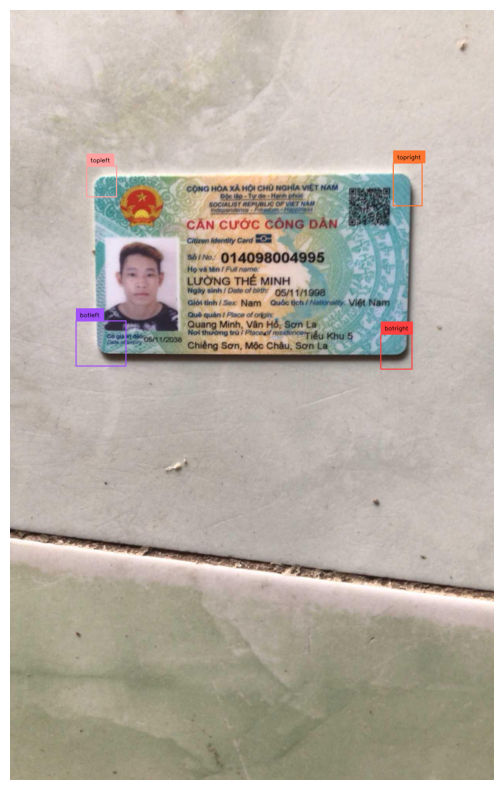

In [6]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))